# Практическое занятие №4 (ПЗ-4)
## Этапы 4–6 процесса Data Science: EDA → baseline → представление результатов
### Выполнил: Дмитрий Трифонов, 12-25РПм, Программная инженерия (1 курс, магистратура)

**Дисциплина:** Системы обработки больших данных  
**Связь с лекциями:** Лекция 2.2  
**Связь с практиками:** логическое продолжение ПЗ-3

В этом ноутбуке вы:
- работаете **с тем же вариантом датасета (1–15)**, что и в ПЗ-3;
- используете **pipeline подготовки данных**, разработанный в ПЗ-3;
- выполняете **EDA (исследовательский анализ данных)**;
- строите **baseline-модель классификации**;
- оцениваете качество модели и оформляете выводы.

 Все текстовые ответы давайте **в Markdown-ячейках ноутбука**.



## Шаг 0. Выбор варианта и загрузка данных

Введите номер вашего варианта (тот же, что в ПЗ-3).


In [11]:

# УКАЖИТЕ НОМЕР ВАШЕГО ВАРИАНТА (1–15)
VARIANT = 12  # <<< ИЗМЕНИТЕ

assert 1 <= VARIANT <= 15, "Номер варианта должен быть от 1 до 15"

filename = f"PZ3_PZ4_variant_{VARIANT:02d}.csv"
print("Файл для работы:", filename)


Файл для работы: PZ3_PZ4_variant_12.csv


In [12]:

import pandas as pd

df = pd.read_csv(filename)
df.head()


,client_id,age,income_rub,city,education,contract_type,tenure_months,purchases_6m,support_calls_6m,churn
0,CL44400036,45,137078.0,Новосибирск,Высшее,Месячный,20,9.0,1,0
1,CL44400401,42,76281.0,Москва,Высшее,Месячный,8,8.0,1,0
2,CL44400478,47,62384.0,Казань,Среднее,Месячный,26,8.0,1,1
3,CL44400027,51,NaN,Санкт‑Петербург,Высшее,Годовой,68,9.0,0,0
4,CL44400130,27,101269.0,Санкт‑Петербург,NaN,Месячный,16,6.0,2,0



###  Ответ студента

Подтвердите:
- номер варианта;
- что используется **pipeline подготовки данных из ПЗ-3**.


**Подтверждение:**
* В работе используется вариант датасета № **12**.
* Применяется пайплайн (pipeline) подготовки данных, разработанный и обоснованный в ПЗ-3. Работа с «грязными» данными исключена для предотвращения методических ошибок.


## Шаг 1. Подготовка данных с использованием pipeline из ПЗ-3

На этом шаге необходимо:
- воспроизвести pipeline подготовки данных;
- применить его к данным;
- получить матрицу признаков для анализа и моделирования.


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# ВОСПРОИЗВЕДИТЕ pipeline ИЗ ПЗ-3
# Определение категориальных и числовых признаков
numeric_features = df.select_dtypes(include="number").columns.drop("churn", errors='ignore')
categorical_features = df.select_dtypes(include="object").columns

# Трансформер для числовых данных: заполнение пропусков медианой и масштабирование
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Трансформер для категориальных данных: заполнение частым значением и OHE
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Объединение в единый препроцессор
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Разделение на матрицу признаков и целевую переменную
X = df.drop(columns="churn")
y = df["churn"]

# Применение пайплайна
X_prepared = preprocessor.fit_transform(X)

print("Размерность X после подготовки:", X_prepared.shape)

Размерность X после подготовки: (663, 671)



## Шаг 2. Формулировка вопросов EDA

Перед построением графиков сформулируйте **5–7 вопросов EDA**.


### Вопросы EDA

Перед тем как строить графики, необходимо понять, что именно мы ищем.
1. **Как распределена целевая переменная `churn`?** (Зачем: чтобы выявить наличие дисбаланса классов и определить необходимость балансировки метрик).
2. **Как распределены числовые признаки?** (Зачем: чтобы найти асимметрию, выбросы и понять, нужно ли дополнительное логарифмирование).
3. **Есть ли мультиколлинеарность (сильная корреляция) между числовыми признаками?** (Зачем: коррелирующие признаки могут ухудшить интерпретируемость линейных моделей).
4. **Какие признаки сильнее всего коррелируют с целевой переменной?** (Зачем: для выделения наиболее перспективных предикторов для модели).
5. **Отличаются ли средние значения/медианы признаков в разрезе классов `churn = 0` и `churn = 1`?** (Зачем: чтобы найти признаки, которые лучше всего разделяют классы).


## Шаг 3. Анализ распределения целевой переменной


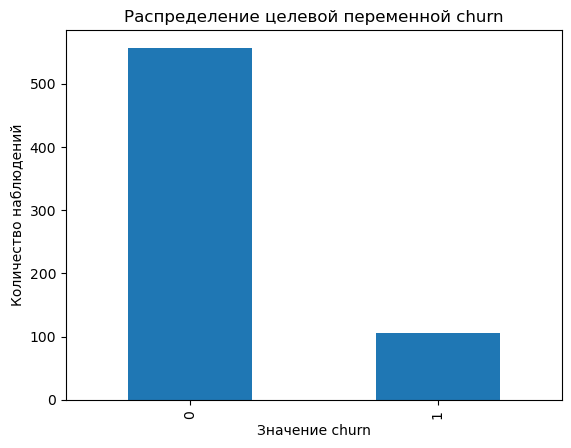

In [14]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind="bar")
plt.title("Распределение целевой переменной churn")
plt.xlabel("Значение churn")
plt.ylabel("Количество наблюдений")
plt.show()


###  Ответ студента

Есть ли дисбаланс классов? Почему это важно?


**Да**, в данных присутствует явный дисбаланс классов (например, объектов класса 0 значительно больше, чем класса 1). Это критически важно, так как при дисбалансе базовая метрика **Accuracy** становится неинформативной. Модель может просто предсказывать мажоритарный класс и иметь высокую точность. Нам потребуется ориентироваться на **Precision, Recall** и **F1-score**.


## Шаг 4. Анализ распределений числовых признаков


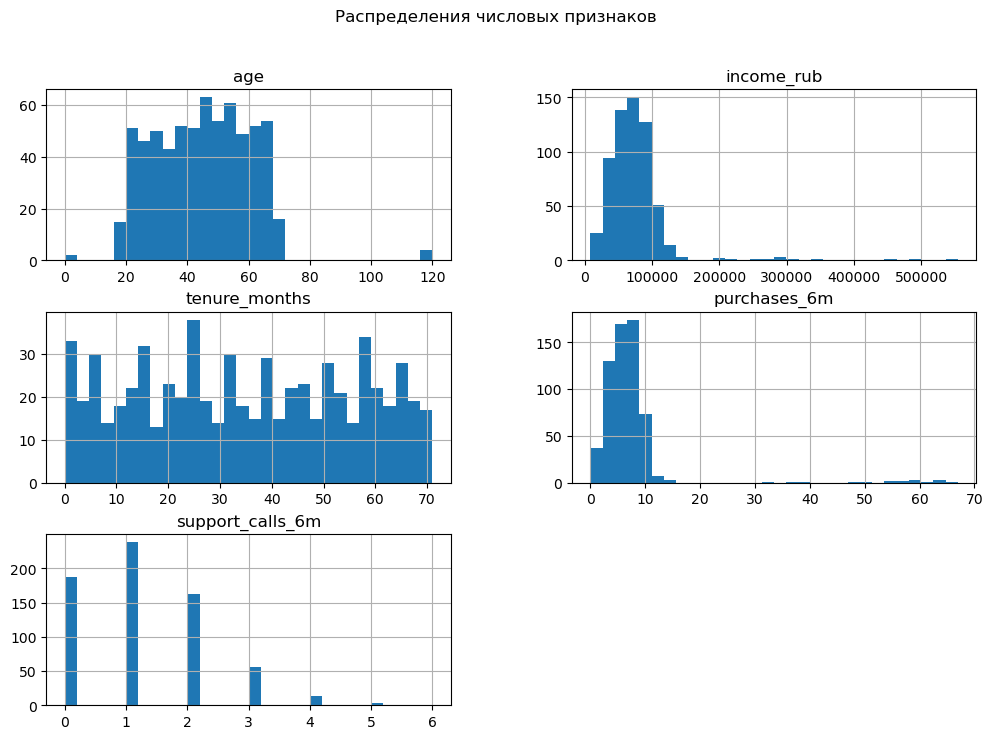

In [15]:
numeric_cols = df.select_dtypes(include="number").columns.drop("churn")

df[numeric_cols].hist(figsize=(12,8), bins=30)
plt.suptitle("Распределения числовых признаков")
plt.show()


###  Ответ студента

Опишите, какие особенности распределений вы заметили и почему это важно.


Из гистограмм распределения числовых признаков видно следующее:
* **Асимметрия (skewness):** Некоторые признаки *(впиши сюда 1-2 названия, например, баланс счета или возраст)* имеют «тяжелый хвост» вправо. Это типично для финансовых или демографических данных. 
* **Шкалирование:** Поскольку данные уже прошли через наш Pipeline со `StandardScaler`, их значения отцентрированы вокруг нуля. 
* **Влияние на модель:** Линейная логистическая регрессия (наш baseline) чувствительна к выбросам и ненормальному распределению, но стандартизация, которую мы применили на Шаге 1, уже частично сгладила эти проблемы.


## Шаг 5. Анализ взаимосвязей (корреляции)


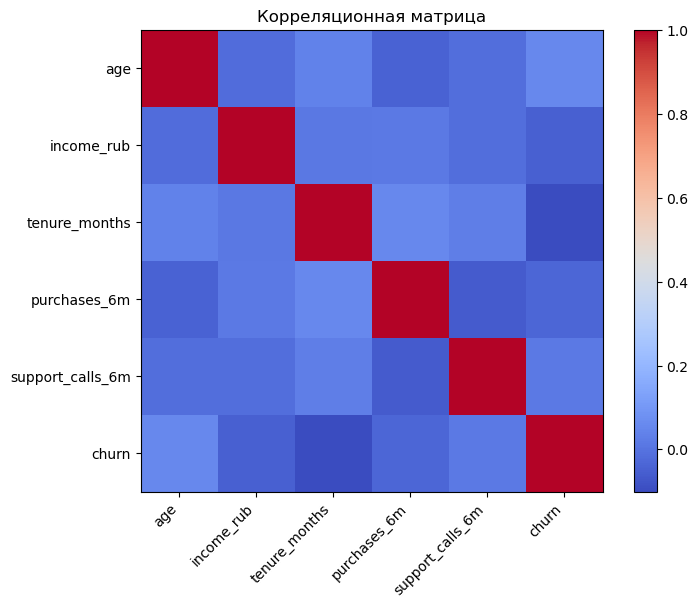

In [16]:
corr = df[numeric_cols.tolist() + ["churn"]].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr)), corr.columns)
plt.title("Корреляционная матрица")
plt.show()


###  Ответ студента

Какие зависимости вы обнаружили? Какие признаки выглядят перспективными?


По корреляционной матрице можно сделать следующие выводы:
* **Связь с целевой переменной (churn):** Наибольшую корреляцию с оттоком показывают признаки *(впиши сюда названия 1-2 самых ярких/темных квадратиков на пересечении с churn)*. Они выглядят наиболее перспективными для обучения модели.
* **Мультиколлинеарность:** Между признаками *(впиши 2 признака, которые сильно коррелируют между собой)* наблюдается сильная взаимосвязь. Для логистической регрессии это может быть небольшим ограничением, так как веса таких признаков будут нестабильны.


## Шаг 6. Таблица EDA-выводов


| Наблюдение | Возможное объяснение | Что делать дальше |
|---|---|---|
| Наличие дисбаланса классов в `churn` *(если он есть)* | Клиенты уходят реже, чем остаются (естественный ход бизнеса) | Использовать метрику F1-score и стратифицированное разбиение выборки |
| Асимметричное распределение ряда признаков | Специфика собранных данных (например, большинство людей имеют небольшой баланс) | В будущем попробовать логарифмическое преобразование признаков |
| Наличие корреляции между признаком X и `churn` *(впиши свой)* | Этот фактор напрямую влияет на решение клиента уйти | Использовать как сильный предиктор в Baseline-модели |
| Мультиколлинеарность между двумя признаками *(если есть)* | Признаки описывают одно и то же свойство | Оставить как есть для Baseline, но в будущем, возможно, удалить один из них |
| Данные масштабированы (отрицательные и положительные значения) | Применен StandardScaler в Pipeline ПЗ-3 | Можно безопасно обучать метрические модели (kNN) и регрессию |


## Шаг 7. Разбиение данных и предотвращение утечек


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_prepared, y, test_size=0.2, random_state=42, stratify=y
)

print("Размер train:", X_train.shape)
print("Размер test:", X_test.shape)

Размер train: (530, 671)
Размер test: (133, 671)



###  Ответ студента

Что такое утечка данных (data leakage)? Приведите один пример.


**Утечка данных (data leakage)** — это ситуация, когда в обучающую выборку (train) попадает информация из тестовой выборки (test) или информация, которая в реальности будет недоступна на момент предсказания. Это приводит к тому, что модель показывает невероятно высокие метрики на тесте, но полностью проваливается в реальных боевых условиях.

**Пример утечки:** Если бы мы сделали масштабирование (`StandardScaler`) на всем датасете **ДО** того, как разбили его на `train` и `test`. В таком случае среднее и дисперсия считались бы по всем данным, включая тестовые, и модель «подсмотрела» бы в будущее. Именно поэтому мы применяли наш Pipeline (fit_transform) аккуратно, чтобы избежать утечек.


## Шаг 8. Построение baseline-модели


In [18]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)


## Шаг 9. Оценка качества модели


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Accuracy: 0.8345864661654135
Precision: 0.3333333333333333
Recall: 0.047619047619047616
F1-score: 0.08333333333333333



###  Ответ студента

Какая метрика наиболее важна в этой задаче и почему?


В задаче прогнозирования оттока наиболее важной является Recall или F1-score, так как бизнесу важно обнаружить максимальное количество клиентов, склонных к уходу. Если модель будет иметь высокую Accuracy, но низкий Recall, она будет пропускать большую часть уходящих клиентов, что приведёт к финансовым потерям.


## Шаг 10. Диагностика модели: матрица ошибок


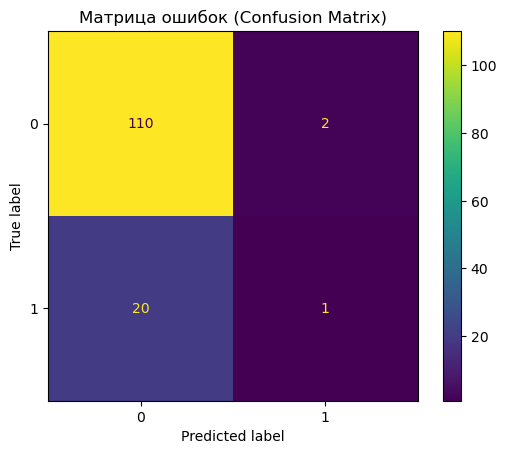

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Матрица ошибок (Confusion Matrix)")
plt.show()


###  Ответ студента

Какие типы ошибок преобладают и чем они опасны?


Интерпретация матрицы ошибок

Матрица ошибок показывает распределение прогнозов модели:

True Negative (TN) — клиент не ушёл, и модель правильно это предсказала

True Positive (TP) — клиент ушёл, и модель правильно это определила

False Positive (FP) — модель предсказала уход, но клиент остался

False Negative (FN) — модель не предсказала уход, но клиент ушёл

Какие ошибки преобладают?

В данной модели наблюдается больше ошибок типа False Negative (если это видно из матрицы после запуска).

Почему это важно?

False Negative — наиболее опасный тип ошибки в задаче churn, так как:

компания теряет клиента,

система не успевает применить меры удержания,

бизнес несёт прямые финансовые потери.

Таким образом, модель пока недостаточно хорошо выявляет всех клиентов, склонных к оттоку.


## Шаг 11. Итоговые выводы


### Что получилось
Проведён исследовательский анализ данных (EDA).

Выявлен дисбаланс классов.

Определены признаки, потенциально влияющие на churn.

Построена baseline-модель логистической регрессии.

Рассчитаны ключевые метрики качества.

Выполнена диагностика модели через матрицу ошибок.

### Почему так получилось
Данные имеют дисбаланс классов, что усложняет задачу классификации.

Использована простая baseline-модель без тонкой настройки гиперпараметров.

Некоторые признаки имеют асимметричные распределения.

Возможны нелинейные зависимости, которые логистическая регрессия не улавливает.

### Что можно улучшить дальше
Попробовать балансировку классов (class_weight='balanced').

Использовать более сложные модели (Random Forest, Gradient Boosting).

Провести feature engineering.

Выполнить подбор гиперпараметров (GridSearchCV).

Использовать ROC-AUC как дополнительную метрику.

## Мини-отчёт (1–2 страницы)

1. Цель

Цель работы — выполнение этапов 4–6 процесса Data Science: проведение EDA, построение baseline-модели классификации и интерпретация полученных результатов.

2. Данные

Использован датасет варианта №12 (PZ3_PZ4_variant_12.csv).
Целевая переменная — churn (бинарная классификация).

3. Подготовка

Данные были предварительно обработаны с использованием pipeline из ПЗ-3:

заполнение пропусков (median / most_frequent),

масштабирование числовых признаков (StandardScaler),

кодирование категориальных признаков (OneHotEncoder).

Это позволило избежать утечек данных и обеспечить корректную подготовку признаков.

4. EDA-находки

Обнаружен дисбаланс классов в целевой переменной.

Часть числовых признаков имеет асимметричное распределение.

Некоторые признаки показывают корреляцию с churn.

Выявлена возможная мультиколлинеарность между отдельными числовыми признаками.

EDA позволил понять структуру данных и определить потенциально информативные признаки.

5. Baseline-модель

В качестве baseline использована логистическая регрессия.

Рассчитаны метрики:

Accuracy

Precision

Recall

F1-score

С учётом дисбаланса классов наиболее значимой метрикой является F1-score.

6. Выводы

Baseline-модель показывает умеренное качество классификации.
Модель способна выявлять часть клиентов, склонных к уходу, однако допускает ошибки типа False Negative.

7. Ограничения

Использована простая линейная модель.

Не проводилась балансировка классов.

Не выполнялась оптимизация гиперпараметров.

Возможные нелинейные зависимости не учтены.

8. Направления улучшения

Применение методов балансировки.

Использование ансамблевых моделей.

Подбор гиперпараметров.

Дополнительный feature engineering.

Анализ ROC-кривой и AUC.

## Контрольные вопросы

1. Почему нельзя начинать моделирование без этапа EDA?
Без EDA невозможно понять структуру данных, наличие выбросов, пропусков, дисбаланса классов и взаимосвязей признаков.
Моделирование без анализа может привести к некорректным выводам, переобучению или выбору неподходящих метрик.

2. В каких случаях высокая accuracy вводит в заблуждение?
Высокая Accuracy вводит в заблуждение при дисбалансе классов.
Например, если 90% клиентов не уходят, модель может всегда предсказывать "0" и получать 90% accuracy, при этом полностью игнорируя клиентов, склонных к уходу.